## Step 1

Imports and parameter initialization

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from collections import defaultdict, deque
import random
import math
import os
from tqdm import tqdm

# random seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# constants
ROAD_LENGTH = 100 * 1000  # total road length in meters
RSU_SPACING = 1000   # 1 km between RSUs
RSU_COUNT = (ROAD_LENGTH // RSU_SPACING) + 1
RSU_RADIUS = 500     # coverage radius in meters
CACHE_SIZE_RSU = 200 # MBs
CACHE_SIZE_VEHICLE = 200 # MBs
VEHICLE_COUNT = 1510
VEHICLE_SPEED = 15   # m/s
USERS_PER_VEHICLE = 4

## Step 2

Dataset processing

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# -----------------------------
# 1. Load raw datasets
# -----------------------------
ratings_dataset = pd.read_csv("ratings.dat", sep="::", engine="python",
                      names=["UserID", "MovieID", "Rating", "Timestamp"])

users = pd.read_csv("users.dat", sep="::", engine="python",
                    names=["UserID", "Gender", "Age", "Occupation", "Zip-code"])

movies = pd.read_csv("movies.dat", sep="::", engine="python",
                     names=["MovieID", "Title", "Genres"], encoding="ISO-8859-1")

# -----------------------------
# 2. Filter ratings to valid user/movie metadata
# -----------------------------
valid_user_ids = set(users['UserID'])
valid_movie_ids = set(movies['MovieID'])

ratings_dataset = ratings_dataset[
    ratings_dataset['UserID'].isin(valid_user_ids) &
    ratings_dataset['MovieID'].isin(valid_movie_ids)
]

# -----------------------------
# 3. Time-based train/test split (after filtering)
# -----------------------------
ratings_dataset = ratings_dataset.sort_values("Timestamp").reset_index(drop=True)
split_idx = int(len(ratings_dataset) * 0.98)
train_ratings = ratings_dataset.iloc[:split_idx]
test_ratings = ratings_dataset.iloc[split_idx:]

# -----------------------------
# 4. Map UserIDs and MovieIDs to 0-based indices
# -----------------------------
user_id_to_idx = {uid: idx for idx, uid in enumerate(sorted(valid_user_ids))}
movie_id_to_idx = {mid: idx for idx, mid in enumerate(sorted(valid_movie_ids))}

# -----------------------------
# 5. Build ratings matrix (User × Movie)
# -----------------------------
num_users = len(user_id_to_idx)
num_movies = len(movie_id_to_idx)
ratings_matrix = np.zeros((num_users, num_movies))

for row in train_ratings.itertuples():
    u_idx = user_id_to_idx[row.UserID]
    m_idx = movie_id_to_idx[row.MovieID]
    ratings_matrix[u_idx, m_idx] = row.Rating

# -----------------------------
# 6. Build user feature matrix (Gender, Age, Occupation, Zip-code)
# -----------------------------
users = users.set_index("UserID").loc[sorted(valid_user_ids)].copy()
users["Gender"] = LabelEncoder().fit_transform(users["Gender"])
users["Zip-code"] = LabelEncoder().fit_transform(users["Zip-code"])
scaler = StandardScaler()
users[["Age", "Zip-code"]] = scaler.fit_transform(users[["Age", "Zip-code"]])
# zip code is not used in paper
user_features = users[["Gender", "Age", "Occupation"]].values

# -----------------------------
# 7. Build genre matrix (Movie × Genre)
# -----------------------------
movies = movies.set_index("MovieID").loc[sorted(valid_movie_ids)].copy()
all_genres = sorted(set(g for gs in movies["Genres"].str.split('|') for g in gs))
genre_to_idx = {g: i for i, g in enumerate(all_genres)}

def build_genre_vector(genre_str):
    vec = np.zeros(len(all_genres))
    for g in genre_str.split('|'):
        if g in genre_to_idx:
            vec[genre_to_idx[g]] = 1
    return vec

movies["GenreVec"] = movies["Genres"].apply(build_genre_vector)
genre_matrix = np.vstack(movies["GenreVec"].values)

# -----------------------------
# 8. Summary Output
# -----------------------------
print(f"Ratings matrix shape: {ratings_matrix.shape}")     # e.g., (6040, 3883)
print(f"User features shape: {user_features.shape}")       # e.g., (6040, 3)
print(f"Genre matrix shape: {genre_matrix.shape}")         # e.g., (3883, 18)

Ratings matrix shape: (6040, 3883)
User features shape: (6040, 3)
Genre matrix shape: (3883, 18)


## Step 3

RSUs and vehicles initialization

Initialized 101 RSUs and 1510 vehicles.


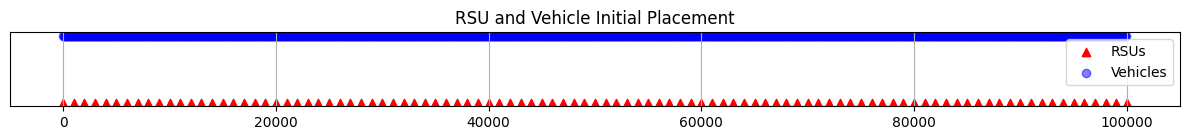

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Initialize RSUs (even spacing)
# -----------------------------
rsus = []
for i in range(RSU_COUNT):
    rsu = {
        'id': i,
        'position': i * RSU_SPACING,
        'cache': set(),  # content IDs
    }
    rsus.append(rsu)

# -----------------------------
# 2. Uniformly distribute vehicles along the road
# -----------------------------
vehicles = []
vehicle_positions = np.linspace(0, ROAD_LENGTH, VEHICLE_COUNT, endpoint=False)

# -----------------------------
# 3. Assign 4 unique users per vehicle and find corresponding RSU
# -----------------------------
available_user_indices = np.arange(len(user_features))
np.random.shuffle(available_user_indices)

assert VEHICLE_COUNT * USERS_PER_VEHICLE <= len(available_user_indices), "Not enough users available!"

for i, pos in enumerate(vehicle_positions):
    user_start = i * USERS_PER_VEHICLE
    user_ids = available_user_indices[user_start:user_start + USERS_PER_VEHICLE].tolist()

    # Find the RSU this vehicle is within range of
    rsu_index = None
    for j, rsu in enumerate(rsus):
        if abs(pos - rsu['position']) <= RSU_RADIUS:
            rsu_index = j
            break
    assert rsu_index is not None, f"Vehicle {i} at pos {pos} not within any RSU range"

    vehicle = {
        'id': i,
        'initial_position': pos,
        'position': pos,
        'speed': VEHICLE_SPEED,
        'users': user_ids,   # indices into user_features / ratings_matrix
        'cache': set(),      # content IDs
        'initial_rsu_index': rsu_index,
        'rsu_index': rsu_index,  # index of the associated RSU
    }
    vehicles.append(vehicle)

print(f"Initialized {len(rsus)} RSUs and {len(vehicles)} vehicles.")

# Visualize RSU and vehicle placement
rsu_positions = [r['position'] for r in rsus]
vehicle_positions_plot = [v['position'] for v in vehicles]

plt.figure(figsize=(12, 1.5))
plt.scatter(rsu_positions, np.zeros_like(rsu_positions), label='RSUs', marker='^', c='red')
plt.scatter(vehicle_positions_plot, np.ones_like(vehicle_positions_plot), label='Vehicles', marker='o', c='blue', alpha=0.5)
plt.title("RSU and Vehicle Initial Placement")
plt.yticks([])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 4

Federated Learning and global model training


A) Core functions needed for simulation

In [4]:
# Constants for timing
T_train = 2.5    # seconds
T_inf = 0.5      # seconds
ROUND_DURATION = T_train + T_inf
RSU_DIAMETER = 2 * RSU_RADIUS

a1, a2, a3 = 0.4, 0.3, 0.3  # Weights for W_n in formula (13)

def move_vehicles(vehicles):
    for v in vehicles:
        v['position'] += v['speed'] * ROUND_DURATION

def update_vehicle_rsu_assignments(vehicles, rsus):
    for v in vehicles:
        rsu_index = None
        for i, rsu in enumerate(rsus):
            if abs(v['position'] - rsu['position']) <= RSU_RADIUS:
                rsu_index = i
                break
        v['rsu_index'] = rsu_index

def calculate_staying_time(vehicle, rsu):
    Pv = abs(vehicle['position'] - (rsu['position'] - RSU_RADIUS)) # distance from entrance position
    D = RSU_DIAMETER
    return (D - Pv) / vehicle['speed']

def select_vehicles(rsu, vehicles):
    selected = []
    for v in vehicles:
        if v['rsu_index'] != rsu['id']:
            continue
        staying_time = calculate_staying_time(v, rsu)
        if staying_time > ROUND_DURATION:
            v['staying_time'] = staying_time
            selected.append(v)
    return selected

B) AutoEncoder model (global model $ \omega $)

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=100):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

C) Local training function

In [6]:
def train_local_model(model, user_indices, ratings_matrix_norm, epochs=1, lr=1e-2):
    device = next(model.parameters()).device
    model.train()

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # For now doing everything in 1 iteration (not considering e_n from formula 8)
    for _ in range(epochs):
        for u in user_indices:
            input_vec = torch.FloatTensor(ratings_matrix_norm[u]).to(device)
            optimizer.zero_grad()
            output = model(input_vec)
            loss = loss_fn(output, input_vec)
            loss.backward()
            optimizer.step()

    return model.cpu()  # move back to CPU after training

D) Model upload and Model update(aggregation) helper functions

In [7]:
# === radio model (Eqs. 4–6) ===
B = 540000            # 540 KHz
SIGMA2 = 3.98e-15  # from -114 dBm

P_V = 0.002            # W (V2V) == 3dBm
P_S = 1.0            # W (RSU) == 30dBm
P_M = 19.95          # W (MBS) == 43dBm
WIRED_R_RP = 100e6   # 100 Mbps between RSUs (RR,R'), fixed as per paper

PATHLOSS_EXP = 3.0
PL_K = 1.0
SHADOW_FADING_STD_DB = 4  # e.g., σ = 4 dB

def channel_gain(distance_m):
    d = max(distance_m, 1.0)
    path_loss = PL_K / (d ** PATHLOSS_EXP)
    shadow_db = np.random.normal(0, SHADOW_FADING_STD_DB)
    shadow_lin = 10 ** (shadow_db / 10)  # convert dB → linear
    return path_loss * shadow_lin

def rate_v2r(d_m):
    h = channel_gain(d_m)
    return B * math.log2(1.0 + (P_S * h) / SIGMA2)

def compute_vehicle_weight(vehicle, max_vals):
    T_stay = vehicle['staying_time']
    R = rate_v2r(abs(vehicle['position'] - rsus[vehicle['rsu_index']]['position']))  
    c = CACHE_SIZE_VEHICLE

    return (
        a1 * (T_stay / max_vals['T']) +
        a2 * (R / max_vals['R']) +
        a3 * (c / max_vals['C'])
    )

SERVER_LR = 0.01  # η^r

def aggregate_one_upload(global_model, client_model, Wn):
    """
    ω ← ω + η * W_n * (ω_n − ω)
    """
    g = global_model.state_dict()
    s = client_model.state_dict()
    wf = float(Wn)
    for k in g.keys():
        g[k] = g[k] + SERVER_LR * wf * (s[k] - g[k])
    global_model.load_state_dict(g)
    return global_model

E) Federated learning round(Model update)

In [8]:
def federated_round(rsu, vehicles, global_model, ratings_matrix_norm):
    selected_vehicles = select_vehicles(rsu, vehicles)
    if not selected_vehicles:
        return global_model  # no updates

    max_vals = {
        'T': max(v['staying_time'] for v in selected_vehicles),
        'R': 0.0, 
        'C': CACHE_SIZE_VEHICLE  # same for all
    }

    for vehicle in selected_vehicles:
        R = rate_v2r(abs(vehicle['position'] - rsus[vehicle['rsu_index']]['position']))  
        max_vals['R'] = max(max_vals['R'], R)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    for v in selected_vehicles:
        local_model = AutoEncoder(input_dim=ratings_matrix_norm.shape[1]).to(device)
        local_model.load_state_dict(global_model.state_dict())  # download ω

        trained_model = train_local_model(
            local_model,
            v['users'],  # 4 users per vehicle
            ratings_matrix_norm
        )

        W_n = compute_vehicle_weight(v, max_vals)
        global_model = aggregate_one_upload(global_model, trained_model, W_n)

    return global_model

F) Federated learning loop

In [9]:
ratings_matrix_norm = ratings_matrix / 5.0

# Initialize per-RSU model
for rsu in rsus:
    rsu['model'] = AutoEncoder(input_dim=ratings_matrix.shape[1])

num_rounds = 100
for r in range(num_rounds):
    print(f"Round {r+1}")
    
    for rsu in rsus:
        rsu['model'] = federated_round(rsu, vehicles, rsu['model'], ratings_matrix_norm)

    move_vehicles(vehicles)
    update_vehicle_rsu_assignments(vehicles, rsus)

Round 1
Round 2
Round 3
Round 4
Round 5
Round 6
Round 7
Round 8
Round 9
Round 10
Round 11
Round 12
Round 13
Round 14
Round 15
Round 16
Round 17
Round 18
Round 19
Round 20
Round 21
Round 22
Round 23
Round 24
Round 25
Round 26
Round 27
Round 28
Round 29
Round 30
Round 31
Round 32
Round 33
Round 34
Round 35
Round 36
Round 37
Round 38
Round 39
Round 40
Round 41
Round 42
Round 43
Round 44
Round 45
Round 46
Round 47
Round 48
Round 49
Round 50
Round 51
Round 52
Round 53
Round 54
Round 55
Round 56
Round 57
Round 58
Round 59
Round 60
Round 61
Round 62
Round 63
Round 64
Round 65
Round 66
Round 67
Round 68
Round 69
Round 70
Round 71
Round 72
Round 73
Round 74
Round 75
Round 76
Round 77
Round 78
Round 79
Round 80
Round 81
Round 82
Round 83
Round 84
Round 85
Round 86
Round 87
Round 88
Round 89
Round 90
Round 91
Round 92
Round 93
Round 94
Round 95
Round 96
Round 97
Round 98
Round 99
Round 100


## Step 5
Content popularity prediction

A) Core helper functions

In [10]:
import numpy as np
import torch
import torch.nn.functional as F

# === 1. Encode users with the RSU global model ===
def get_encoded_users(autoencoder, ratings_matrix):
    autoencoder.eval()
    with torch.no_grad():
        inputs = torch.FloatTensor(ratings_matrix)
        encoded = autoencoder.encoder(inputs)
    return encoded.numpy()

# === Encode users 
encoded_users = np.zeros((num_users, 100))
with tqdm(total=VEHICLE_COUNT, desc="Encoding users") as pbar:
    for rsu in rsus:
        model = rsu['model']
        rsu_vehicles = [v for v in vehicles if v['initial_rsu_index'] == rsu['id']]

        for vehicle in rsu_vehicles:
            vehicle_ratings_norm = ratings_matrix_norm[vehicle['users']]
            encoded_users[vehicle['users']] = get_encoded_users(model, vehicle_ratings_norm)
            pbar.update(1)

# === 2. User similarity θ_{i,j} based on Eq. (14) ===
def user_similarity(i_ratings, j_ratings, i_info, j_info):
    i_rated = i_ratings > 0
    j_rated = j_ratings > 0
    co_mask = i_rated & j_rated
    if co_mask.sum() == 0:
        return 0.0  # no basis to compare
    
    # per-user means over *their own* rated items (not just co-rated)
    mean_i = i_ratings[i_rated].mean()
    mean_j = j_ratings[j_rated].mean()

    # Pearson on co-rated items, centered by the per-user means above
    xi = i_ratings[co_mask] - mean_i
    xj = j_ratings[co_mask] - mean_j
    denom = (np.linalg.norm(xi) * np.linalg.norm(xj)) + 1e-8
    rating_sim = float(np.dot(xi, xj) / denom)

    # user-info cosine (age, gender, occupation) + THE ENCODED USERDATA
    info_denom = (np.linalg.norm(i_info) * np.linalg.norm(j_info)) + 1e-8
    info_sim = float(np.dot(i_info, j_info) / info_denom)

    return rating_sim * info_sim
                    
# === 3. Creation of Usim{} for each user
def collect_neighbors(user_index, theta_th=0.5):
    U = ratings_matrix.shape[0]
    neighbors = []

    i_ratings = ratings_matrix[user_index]
    i_info  = np.append(user_features[user_index], encoded_users[user_index])

    for j in range(U):
        if j == user_index:
            continue

        j_ratings = ratings_matrix[j]
        j_info = np.append(user_features[j], encoded_users[j])
        theta = user_similarity(i_ratings, j_ratings, i_info, j_info)

        if theta > theta_th:
            rj = ratings_matrix[j]
            rated_mask_j = (rj > 0)
            if not np.any(rated_mask_j):
                continue
            mean_j = rj[rated_mask_j].mean()
            neighbors.append({
                "idx": j,
                "theta": float(theta),
                "mean": float(mean_j),
                "rated_mask": rated_mask_j
            })

    return neighbors


# === 4. Predict missing ratings using Eq. (16) ===
def predict_user_ratings(user_index):
    r_u = ratings_matrix[user_index]
    u_avg = r_u[r_u > 0].mean() if np.any(r_u > 0) else 0
    preds = r_u.copy()

    neighbors = collect_neighbors(user_index)

    for f in range(len(r_u)):
        if r_u[f] > 0:
            continue

        numer, denom = 0, 0
        for nb in neighbors:
            j = nb["idx"]
            if not nb["rated_mask"][f]:
                continue  # neighbor must have rated f
            r_jf = ratings_matrix[j, f]
            numer += nb["theta"] * (r_jf - nb["mean"])
            denom += nb["theta"]

        preds[f] = u_avg + (numer / (denom + 1e-8))

    return preds

Encoding users: 100%|██████████| 1510/1510 [00:00<00:00, 2232.91it/s]


B) Theme preferance, User's interest values

In [11]:
# Eq. (18) & (19) — user theme preference φ_{u,hm}, then φ_{u,f}
# Note: This function uses the PREDICTED RATINGS to compute theme preference
def compute_theme_interest(ratings_u):
    # Global theme prior: P(X(h_m)) ~ fraction of catalog in theme m
    theme_counts = genre_matrix.sum(axis=0)                  # (M,)
    p_global = (theme_counts / (theme_counts.sum() + 1e-8))    # (M,)

    # User "posterior" over themes using predicted ratings as soft support
    # P(X(h_m) | Y(u)) ~ sum_f r_hat_u[f] * ρ_{h_m,f}  normalized
    theme_mass_user = genre_matrix.T @ ratings_u             # (M,)
    p_user = theme_mass_user / (theme_mass_user.sum() + 1e-8)  # (M,)

    # Eq. 18 proxy: φ_{u,h_m} = log P(X(h_m)|Y(u)) / P(X(h_m))
    phi_u_h = np.log((p_user + 1e-8) / (p_global + 1e-8))       # (M,)


    # Eq. 19: correlation between ρ_{:,f} and φ_{u,:}
    # With multi-hot ρ, this reduces to cosine between:
    #   vector_a = ρ_{:,f}   (themes of item f)
    #   vector_b = φ_{u,:}   (theme preference)
    # Which equals dot / (||ρ_{:,f}|| * ||φ||)
    num = genre_matrix @ phi_u_h                             # (F,)
    denom = (np.linalg.norm(genre_matrix, axis=1) *          # ||ρ_{:,f}||
             (np.linalg.norm(phi_u_h) + 1e-8) + 1e-8)
    phi_u_f = num / denom

    return phi_u_h, phi_u_f

C) Request probability

In [12]:
# Eq. (20)–(24)
def request_probability(r_u_f, phi_u_f, ε=5.0, phi_weight=0.3):
    g_r = (r_u_f - r_u_f.min()) / (r_u_f.max() - r_u_f.min() + 1e-8)
    g_phi = (phi_u_f - phi_u_f.min()) / (phi_u_f.max() - phi_u_f.min() + 1e-8)

    p_r = np.exp(ε * g_r)
    p_phi = np.exp(ε * g_phi)

    p_r /= np.sum(p_r)
    p_phi /= np.sum(p_phi)

    return phi_weight * p_r + (1 - phi_weight) * p_phi

D) Vehicle popularity

In [13]:
# Eq. (25)
def compute_vehicle_popularity(users):
    all_probs = np.zeros((num_users, num_movies))

    for u in users:
        r_hat = predict_user_ratings(u)
        _, φ_u_f = compute_theme_interest(r_hat)
        all_probs[u] = request_probability(r_hat, φ_u_f)

    return all_probs.sum(axis=0) / np.sum(all_probs)

E) Global popularity

In [14]:
# Eq. (26)
def compute_rsu_global_popularity(vehicles_with_popularity):
    all_local = np.stack([v['local_popularity'] for v in vehicles_with_popularity])
    return all_local.sum(axis=0) / np.sum(all_local)

F) Popularity prediction loop for all RSUs

In [15]:
with tqdm(total=VEHICLE_COUNT, desc="Vehicle Popularities") as pbar:
    for vehicle in vehicles:
        if vehicle['initial_rsu_index'] is None:
            continue

        # FIXME: I'm using the vehicles initial positions and rsus to calculate popularities. is it ok? after the vehicles had moved through out the federated learning step.
        rsu_model = rsus[vehicle['initial_rsu_index']]['model']
        vehicle_ratings_norm = ratings_matrix_norm[vehicle['users']]
        # FIXME: the paper doesn't use zip-code but it is available in user_features. should we use it or no?
        infos = user_features[vehicle['users'], :3]  # e.g., [age, gender, occupation]
        vehicle['local_popularity'] = compute_vehicle_popularity(vehicle['users'])
        pbar.update(1)

    
for rsu in rsus:
    # FIXME: I'm using the vehicles initial positions and rsus to calculate popularities. is it ok? after the vehicles had moved through out the federated learning step.
    rsu_vehicles = [v for v in vehicles if v['initial_rsu_index'] == rsu['id'] and 'local_popularity' in v]

    if not rsu_vehicles:
        print(f"Warning: RSU {rsu['id']} has no assigned vehicles for popularity computation.")
        rsu['global_popularity'] = np.zeros(genre_matrix.shape[0])  # or skip, or assign None
        continue

    rsu['global_popularity'] = compute_rsu_global_popularity(rsu_vehicles)
    print(f"Rsu number {rsu["id"]}'s popularity shape: {rsu['global_popularity'].shape}")

Vehicle Popularities: 100%|██████████| 1510/1510 [1:07:08<00:00,  2.67s/it]

Rsu number 0's popularity shape: (3883,)
Rsu number 1's popularity shape: (3883,)
Rsu number 2's popularity shape: (3883,)
Rsu number 3's popularity shape: (3883,)
Rsu number 4's popularity shape: (3883,)
Rsu number 5's popularity shape: (3883,)
Rsu number 6's popularity shape: (3883,)
Rsu number 7's popularity shape: (3883,)
Rsu number 8's popularity shape: (3883,)
Rsu number 9's popularity shape: (3883,)
Rsu number 10's popularity shape: (3883,)
Rsu number 11's popularity shape: (3883,)
Rsu number 12's popularity shape: (3883,)
Rsu number 13's popularity shape: (3883,)
Rsu number 14's popularity shape: (3883,)
Rsu number 15's popularity shape: (3883,)
Rsu number 16's popularity shape: (3883,)
Rsu number 17's popularity shape: (3883,)
Rsu number 18's popularity shape: (3883,)
Rsu number 19's popularity shape: (3883,)
Rsu number 20's popularity shape: (3883,)
Rsu number 21's popularity shape: (3883,)
Rsu number 22's popularity shape: (3883,)
Rsu number 23's popularity shape: (3883,)
Rs

## Step 6

Duelling DQN training process

Constants

In [16]:
# ---------------------------
# Paper parameters (Table I)
# ---------------------------
# Reward weights (Eq. 32): λ1+λ2+λ3+λ4=1 and λ1<λ2<λ3<<λ4
LAMBDA = dict(l1=0.001, l2=0.01, l3=0.39, l4=0.599)

# χ scales for reward branches (χ0..χ4)
CHI = dict(c0=1.00, c1=0.95, c2=0.90, c3=0.80, c4=0.50)

# Radio model (Eqs. 4–6)
B = 540_000                 # 540 KHz bandwidth (Hz)
SIGMA2 = 3.98e-15           # σ^2 noise power: -114 dBm -> 3.98e-15 W

# Tx powers (W) from dBm: p_v=3 dBm, p_s=30 dBm, p_M=43 dBm
P_V = 0.002                 # 3 dBm
P_S = 1.0                   # 30 dBm
P_M = 19.95                # 43 dBm

WIRED_R_RP = 100e6          # R_{R,R'} fixed wired (bits/s), as in paper text
MBS_DISTANCE = 100_000.0      # meters (assumption; paper doesn’t fix—tunable)

# Large-scale path loss + log-normal shadowing (used by channel_gain below)
PATHLOSS_EXP = 3.0
PL_K = 1.0
SHADOW_FADING_STD_DB = 4.0  # σ (dB) for shadowing

# DQN training (paper)
GAMMA = 0.99                # ζ (Eq. 35)
LR    = 1e-2                # η_δ (Table I says 0.01)

# Cache/content sizes (bits) — the rate functions output bits/s
CONTENT_SIZE_BITS  = 5 * 1024 * 1024 * 8     # 5 MB per object, in bits
RSU_CACHE_ITEMS    = 400                      # keep as "items"
VEH_CACHE_ITEMS    = 400                      # items
RSU_CACHE_BITS     = RSU_CACHE_ITEMS * CONTENT_SIZE_BITS
VEH_CACHE_BITS     = VEH_CACHE_ITEMS * CONTENT_SIZE_BITS

# Replacement counts when Ω bit = 1 (paper text)
N_S_REPLACE = 30    # N_S
N_V_REPLACE = 15     # N_{v_n}

# Action space Ω = {(0,0),(1,0),(0,1),(1,1)}  -> (update_RSU, update_vehicle)
ACTIONS = [(0,0), (1,0), (0,1), (1,1)]
N_ACTIONS = len(ACTIONS)

# State shaping (fixed-length for the shared DQN)
TOPK_S = 50         # take top-K RSU cache scores
TOPK_V = 20         # take top-K per-vehicle cache scores
MAX_VEH_UNDER_RSU = 8  # cap for state size; pad if fewer


Delay and Reward function

In [17]:
import math
import numpy as np

def channel_gain(distance_m: float) -> float:
    """
    h_n(d) = path_loss(d) * shadow(d)   (paper Sec. III-C)
    We use 1/d^n with log-normal shadowing.
    """
    d = max(distance_m, 1.0)
    path_loss = PL_K / (d ** PATHLOSS_EXP)
    shadow_db = np.random.normal(0.0, SHADOW_FADING_STD_DB)
    shadow_lin = 10 ** (shadow_db / 10.0)
    return path_loss * shadow_lin

# Shannon rates for links
def _rate(power_w, d_m):
    h = channel_gain(d_m)
    return B * math.log2(1.0 + (power_w * h) / SIGMA2)  # bits/s

def rate_v2v(d_m):   return _rate(P_V, d_m)   # Eq. (4)
def rate_v2r(d_m):   return _rate(P_S, d_m)   # Eq. (5)
def rate_v2mbs(d_m): return _rate(P_M, d_m)   # Eq. (6)

# Delays (Eqs. 28–31)
def delay_v2v(d_m):
    R = max(rate_v2v(d_m), 1e-9)
    return CONTENT_SIZE_BITS / R

def delay_v2r(d_m):
    R = max(rate_v2r(d_m), 1e-9)
    return CONTENT_SIZE_BITS / R

def delay_r2r_plus_v2r(d_m):
    # τ_vn,S' = τ_vn,S + (F_f / R_{R,R'})
    return delay_v2r(d_m) + (CONTENT_SIZE_BITS / max(WIRED_R_RP, 1.0))

def delay_mbs(d_m):
    R = max(rate_v2mbs(d_m), 1e-9)
    return CONTENT_SIZE_BITS / R

def compute_reward_from_source(source: str, delays: dict) -> float:
    """
    Eq. (32) – branch by source and apply exp(-λ τ) with χ scale.
    source ∈ {"self","v2v","rsu","neighbor_rsu","mbs"}
    delays: dict with needed τ values (seconds)
    """
    l1, l2, l3, l4 = LAMBDA['l1'], LAMBDA['l2'], LAMBDA['l3'], LAMBDA['l4']
    if source == "self":
        return CHI['c0']  # τ=0

    if source == "v2v":
        τ = delays["v2v"]
        return CHI['c1'] * math.exp(-l1 * τ)

    if source == "rsu":
        τ = delays["v2r"]
        return CHI['c2'] * math.exp(-l2 * τ)

    if source == "neighbor_rsu":
        # Paper uses exp(-(λ2 τ_vn,S + λ3 τ_vn,S')) ; our τ dict stores both legs
        τ_local  = delays["v2r"]
        τ_wired  = delays["r2r"]  # F/R_RR'
        return CHI['c3'] * math.exp(-(l2 * τ_local + l3 * τ_wired))

    if source == "mbs":
        τ = delays["mbs"]
        return CHI['c4'] * math.exp(-l4 * τ)

    return 0.0


Episode initialization & reset

In [18]:
def reset_episode(vehicles, rsus):
    """
    Reset positions, RSU membership, and caches at episode start
    (Algorithm 2, lines 1-3).
    """
    for v in vehicles:
        v['position'] = v['initial_position']
        v['rsu_index'] = v['initial_rsu_index']
        v['cache'] = []                # ordered list (most-popular first)
        v['cache_set'] = set()         # fast membership
    for r in rsus:
        r['cache'] = []
        r['cache_set'] = set()

def _fill_cache_by_popularity(cache_list, cache_set, popularity_vec, capacity_items):
    # Take the highest-popularity, not-yet-cached contents until full.
    top_ids = np.argsort(popularity_vec)[::-1]
    for f in top_ids:
        if len(cache_list) >= capacity_items: break
        if f not in cache_set:
            cache_list.append(int(f))
            cache_set.add(int(f))

def init_caches_from_popularity(rsus, vehicles):
    """
    After popularity prediction (Alg. 1 finished), cache top-ranked contents:
      - RSU: use rsu['global_popularity']  (O_f)
      - Vehicle: use vehicle['local_popularity']  (O_f^{v_n})
    (Paper Sec. IV-A Content Caching)
    """
    # RSUs
    for r in rsus:
        pop = r.get('global_popularity', None)
        if pop is None:  # edge: fill empty
            r['cache'], r['cache_set'] = [], set()
            continue
        r['cache'], r['cache_set'] = [], set()
        _fill_cache_by_popularity(r['cache'], r['cache_set'], pop, RSU_CACHE_ITEMS)

    # Vehicles
    for v in vehicles:
        pop = v.get('local_popularity', None)
        v['cache'], v['cache_set'] = [], set()
        if pop is None:    # default empty
            continue
        _fill_cache_by_popularity(v['cache'], v['cache_set'], pop, VEH_CACHE_ITEMS)


State builder

In [19]:
def _scores_from_ids(ids, score_vec, K):
    if not ids: return np.zeros(K, dtype=np.float32)
    # take top-K by their score
    vals = np.array([score_vec[i] for i in ids], dtype=np.float32)
    order = np.argsort(vals)[::-1][:K]
    out = np.zeros(K, dtype=np.float32)
    out[:len(order)] = vals[order]
    return out

def vehicles_under_rsu(rsu_id, vehicles):
    return [v for v in vehicles if v['rsu_index'] == rsu_id]

def build_state_for_rsu(rsu, vehs_here):
    """
    o(t) = {o_S(t), o_V(t)}. We encode as fixed-length vector:
      - RSU cache: topK_S scores from rsu['global_popularity']
      - Up to MAX_VEH vehicles: each contributes topK_V scores
    """
    S = rsu.get('global_popularity', None)
    rsu_block = _scores_from_ids(rsu['cache'], S, TOPK_S) if S is not None else np.zeros(TOPK_S, np.float32)

    veh_blocks = []
    for k in range(MAX_VEH_UNDER_RSU):
        if k < len(vehs_here):
            v = vehs_here[k]
            Vpop = v.get('local_popularity', None)
            block = _scores_from_ids(v['cache'], Vpop, TOPK_V) if Vpop is not None else np.zeros(TOPK_V, np.float32)
        else:
            block = np.zeros(TOPK_V, np.float32)
        veh_blocks.append(block)

    state = np.concatenate([rsu_block] + veh_blocks, axis=0).astype(np.float32)
    return state

def build_global_state(rsus, vehicles):
    """
    Optional: a global snapshot; if you call the agent per-RSU, you don't need this.
    We'll still expose it (used by evaluate_on_test with one action).
    Concatenate all RSU local states (may be large; for test only).
    """
    states = []
    for r in rsus:
        s = build_state_for_rsu(r, vehicles_under_rsu(r['id'], vehicles))
        states.append(s)
    return np.concatenate(states, axis=0).astype(np.float32)

Update policy

In [20]:
def replace_in_cache_by_popularity(cache_list, cache_set, popularity_vec, n_replace, capacity_items):
    if n_replace <= 0: 
        return
    # victims: lowest-score items currently cached
    if cache_list:
        cur_scores = np.array([popularity_vec[i] for i in cache_list])
        order = np.argsort(cur_scores)             # ascending -> least popular first
        victims = [cache_list[i] for i in order[:n_replace]]
    else:
        victims = []

    # candidates: highest-popularity items not cached yet
    cand_ids = np.argsort(popularity_vec)[::-1]
    added = 0
    for f in cand_ids:
        if f in cache_set: 
            continue
        if victims:
            # evict a victim
            old = victims.pop(0)
            if old in cache_set:
                cache_set.remove(old)
                cache_list.remove(old)
        if len(cache_list) < capacity_items:
            cache_list.append(int(f))
            cache_set.add(int(f))
            added += 1
            if added >= n_replace: 
                break

    # re-sort cache_list by popularity descending (paper: reorder by popularity)
    cache_list.sort(key=lambda fid: popularity_vec[fid], reverse=True)


def update_rsu_on_vehicle_arrival(rsu, vehicle, top_k=10, blend=0.2):
    """
    Heuristic (optional): upon vehicle entering RSU coverage,
    nudge RSU cache toward that vehicle's local popularity.
    - blend controls how many items we actually try to plant (~top_k*blend).
    - preserves Algorithm 2's spirit: we still reorder by RSU global popularity.
    """
    if 'local_popularity' not in vehicle or 'global_popularity' not in rsu:
        return
    v_pop = vehicle['local_popularity']
    s_pop = rsu['global_popularity']

    # candidates: vehicle’s top-K not yet in RSU
    v_top = np.argsort(v_pop)[::-1][:top_k]
    inject = [int(f) for f in v_top if f not in rsu['cache_set']]

    n_inject = max(0, min(len(inject), int(round(top_k * blend))))
    if n_inject == 0:
        return

    # evict RSU’s least-popular items
    if rsu['cache']:
        cur_scores = np.array([s_pop[f] for f in rsu['cache']])
        victims = [rsu['cache'][i] for i in np.argsort(cur_scores)[:n_inject]]
    else:
        victims = []

    for _ in range(n_inject):
        if not inject: break
        f_new = inject.pop(0)
        if victims:
            f_old = victims.pop(0)
            if f_old in rsu['cache_set']:
                rsu['cache_set'].remove(f_old)
                rsu['cache'].remove(f_old)
        if len(rsu['cache']) < RSU_CACHE_ITEMS:
            rsu['cache'].append(f_new)
            rsu['cache_set'].add(f_new)

    # reorder by the RSU's *global* popularity (paper: "reordered according to global popularity")
    rsu['cache'].sort(key=lambda fid: s_pop[fid], reverse=True)

def _stamp_prev_rsu_indices(vehicles):
    for v in vehicles:
        v['prev_rsu_index'] = v.get('rsu_index', None)


Environment step

In [21]:
def rsu_neighbors_map(rsus):
    nbrs = {}
    for r in rsus:
        rid = r['id']
        nbrs[rid] = [n for n in (rid-1, rid+1) if 0 <= n < len(rsus)]
    return nbrs

def find_source_and_delays(req_vehicle, content_id, rsu, vehs_here, rsus, neighbors):
    """
    Figure out where we can get 'content_id' from (priority order per paper):
      self -> V2V (same RSU) -> RSU -> neighbor RSU (via wired) -> MBS
    Returns: source string and dict of delays to feed the reward.
    """
    # 0) local cache
    if content_id in req_vehicle['cache_set']:
        return "self", dict()

    # helper distances
    def dist_to_rsu(v, r): return abs(v['position'] - r['position'])

    # 1) V2V inside same RSU
    for other in vehs_here:
        if other['id'] == req_vehicle['id']: 
            continue
        if content_id in other['cache_set']:
            # approximate distance for V2V
            d = abs(req_vehicle['position'] - other['position'])
            return "v2v", dict(v2v=delay_v2v(d))

    # 2) current RSU
    if content_id in rsu['cache_set']:
        d = dist_to_rsu(req_vehicle, rsu)
        return "rsu", dict(v2r=delay_v2r(d))

    # 3) neighbor RSU via wired
    for nid in neighbors[rsu['id']]:
        nr = rsus[nid]
        if content_id in nr['cache_set']:
            d = dist_to_rsu(req_vehicle, rsu)     # vehicle→local RSU
            return "neighbor_rsu", dict(v2r=delay_v2r(d),
                                        r2r=CONTENT_SIZE_BITS / WIRED_R_RP)

    # 4) MBS
    return "mbs", dict(mbs=delay_mbs(MBS_DISTANCE))

def step_environment_for_rsu(
    rsus_global, rsu, vehicles, batch, q_net, epsilon, replay, device, n_actions, neighbors
):
    vehs_here = vehicles_under_rsu(rsu['id'], vehicles)
    if not vehs_here or not batch:
        return None

    # state s
    s = build_state_for_rsu(rsu, vehs_here)

    # ε-greedy action
    if random.random() < epsilon:
        a = random.randrange(n_actions)
    else:
        with torch.no_grad():
            qv = q_net(torch.from_numpy(s).unsqueeze(0).to(device))
            a = int(torch.argmax(qv, dim=1).item())
    ΩS, ΩV = ACTIONS[a]

    # RSU cache update
    if ΩS == 1:
        replace_in_cache_by_popularity(
            rsu['cache'], rsu['cache_set'], rsu['global_popularity'],
            N_S_REPLACE, RSU_CACHE_ITEMS
        )

    # reward accumulation
    total_reward = 0.0
    for (veh, content_id) in batch:
        if ΩV == 1 and 'local_popularity' in veh:
            replace_in_cache_by_popularity(
                veh['cache'], veh['cache_set'], veh['local_popularity'],
                N_V_REPLACE, VEH_CACHE_ITEMS
            )

        src, dly = find_source_and_delays(veh, content_id, rsu, vehs_here, rsus_global, neighbors)
        γ = compute_reward_from_source(src, dly)
        total_reward += γ

    # next state
    s1 = build_state_for_rsu(rsu, vehicles_under_rsu(rsu['id'], vehicles))

    # push transition
    replay.push(s, a, total_reward, s1)

    return a, total_reward


# --- movement: advance all vehicles by dt seconds (m/s * s -> meters) ---
def step_move_vehicles(vehicles, dt, road_length=ROAD_LENGTH):
    """
    Move each vehicle forward by v['speed'] * dt meters.
    Positions are wrapped on a circular road of length `road_length`
    so vehicles never leave the simulation domain.

    Args:
        vehicles (list[dict]): each has keys 'position' (m) and 'speed' (m/s)
        dt (float): elapsed time in seconds since the previous timestamp
        road_length (float): total road length in meters
    """
    if dt <= 0:
        return
    L = float(road_length)
    for v in vehicles:
        # advance
        new_pos = v['position'] + v['speed'] * dt
        # wrap around road
        v['position'] = new_pos % L

        # (optional) keep a running distance or laps counter
        # v['distance_traveled'] = v.get('distance_traveled', 0.0) + v['speed'] * dt

    # NOTE: we intentionally DO NOT update RSU membership here.
    # Call update_vehicle_rsu_assignments(vehicles, rsus) right after this function,
    # so coverage is recomputed with the new positions.


def step_move_vehicles_clamped(vehicles, dt, road_length=ROAD_LENGTH):
    if dt <= 0:
        return
    L = float(road_length)
    for v in vehicles:
        v['position'] = max(0.0, min(L, v['position'] + v['speed'] * dt))

Request batches

In [22]:
from collections import defaultdict

def build_requests_by_timestamp(df_ratings, user_id_to_idx, movie_id_to_idx):
    ts_to_reqs = defaultdict(list)  # ts -> list[(u_idx, f_idx)]
    for row in df_ratings.itertuples(index=False):
        u = user_id_to_idx.get(row.UserID, None)
        f = movie_id_to_idx.get(row.MovieID, None)
        if u is not None and f is not None:
            ts_to_reqs[row.Timestamp].append((u, f))
    ts_sorted = sorted(ts_to_reqs.keys())
    return ts_sorted, ts_to_reqs

def build_user_to_vehicle_map(vehicles):
    m = {}
    for v in vehicles:
        for u in v['users']:
            m[u] = v['id']
    return m

def group_requests_for_timestamp(ts_requests, vehicles, user2veh):
    """
    Returns dict[rsu_id] -> list of (vehicle_obj, content_id)
    """
    rsu_batches = defaultdict(list)
    for (u_idx, f_idx) in ts_requests:
        vid = user2veh.get(u_idx, None)
        if vid is None:
            continue
        veh = vehicles[vid]
        rid = veh.get('rsu_index', None)
        if rid is None:
            continue
        rsu_batches[rid].append((veh, f_idx))
    return rsu_batches

Training

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import random
from collections import deque, namedtuple

# -----------------------------
# Dueling DQN (per Table I)
# - one hidden layer (128) in the Advantage head
# - one hidden layer (128) in the Value head
# - shared feature layer feeding both heads
# -----------------------------
class DuelingDQN(nn.Module):
    def __init__(self, state_dim: int, n_actions: int):
        super().__init__()
        # shared feature extractor (kept lean to emphasize the two 128-heads as in the table)
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
        )
        # state-value stream (1 hidden layer, 128 units)
        self.value = nn.Sequential(
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
        # advantage stream (1 hidden layer, 128 units)
        self.adv = nn.Sequential(
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        # x: [B, state_dim]
        z = self.feature(x)
        V = self.value(z)                    # [B, 1]
        A = self.adv(z)                      # [B, n_actions]
        Q = V + (A - A.mean(dim=1, keepdim=True))   # Eq. (33): dueling combination
        return Q


# -----------------------------
# Uniform Replay Buffer
# -----------------------------
Transition = namedtuple('Transition', 's a r s1')

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buf = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buf)

    def push(self, s: np.ndarray, a: int, r: float, s1: np.ndarray):
        # store as numpy for quick sampling; convert to tensors at train step
        self.buf.append(Transition(s.astype(np.float32), int(a), float(r), s1.astype(np.float32)))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        s   = np.stack([b.s  for b in batch], axis=0)
        a   = np.array([b.a  for b in batch], dtype=np.int64)
        r   = np.array([b.r  for b in batch], dtype=np.float32)
        s1  = np.stack([b.s1 for b in batch], axis=0)
        return s, a, r, s1


ENABLE_ARRIVAL_NUDGE = False

def train_dqn_shared(
    rsus, vehicles,
    train_ratings, user_id_to_idx, movie_id_to_idx,
    episodes=3,
    batch_size=128,
    replay_cap=500_000,
    epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.999,
    target_sync=1000,
    lr=LR, gamma=GAMMA,
    device=None,
    train_fraction=1.0,         # <--- NEW: fraction of training timeline to use (0<..<=1)
    use_prefix_window=True,      # <--- NEW: keep first fraction to preserve chronology
    warm_up_min_samples = 10_000
):
    """
    Shared DQN across all RSUs. Chronological timestamps; vehicles move by real Δt.
    """
    global rsus_global
    rsus_global = rsus

    # ----- chronological index of requests
    ts_list, ts_to_reqs = build_requests_by_timestamp(train_ratings, user_id_to_idx, movie_id_to_idx)
    if len(ts_list) == 0:
        raise ValueError("train set produced no timestamps/requests.")

    # ----- FRACTION: keep a contiguous slice to preserve motion realism
    if train_fraction < 1.0:
        n_keep = max(1, int(len(ts_list) * train_fraction))
        if use_prefix_window:
            ts_list = ts_list[:n_keep]          # earliest portion
        else:
            # center window (alternative)
            start = max(0, (len(ts_list) - n_keep) // 2)
            ts_list = ts_list[start:start+n_keep]

    # ----- create model(s)
    reset_episode(vehicles, rsus)
    init_caches_from_popularity(rsus, vehicles)
    dummy = build_state_for_rsu(rsus[0], vehicles_under_rsu(rsus[0]['id'], vehicles))
    state_dim = dummy.shape[0]

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[DQN] device = {device}")

    q_net  = DuelingDQN(state_dim, N_ACTIONS).to(device)
    tgt_net = DuelingDQN(state_dim, N_ACTIONS).to(device)
    tgt_net.load_state_dict(q_net.state_dict())
    q_net.train(); tgt_net.train()

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    replay = ReplayBuffer(capacity=replay_cap)
    neighbors = rsu_neighbors_map(rsus)

    epsilon = epsilon_start
    epsilon_reset_rate = 0.2
    global_step = 0

    for ep in range(1, episodes+1):
        print(f"epsilon at the start of episode: {ep} is {epsilon}")
        reset_episode(vehicles, rsus)
        init_caches_from_popularity(rsus, vehicles)
        _stamp_prev_rsu_indices(vehicles)
        user2veh = build_user_to_vehicle_map(vehicles)
        epsilon = max(epsilon, epsilon_start - (epsilon_start * epsilon_reset_rate * ep))

        # prev_ts must come from the (possibly sliced) list
        prev_ts = ts_list[0]

        pbar = tqdm(ts_list, desc=f"Episode {ep}/{episodes}", leave=False)
        for t in pbar:
            # ---- 1) movement by real elapsed time ----
            dt = max(0, t - prev_ts)
            prev_ts = t
            if dt > 0:
                step_move_vehicles(vehicles, dt)
                update_vehicle_rsu_assignments(vehicles, rsus)

                if ENABLE_ARRIVAL_NUDGE:
                    ARRIVAL_TOPK  = 10
                    ARRIVAL_BLEND = 0.2
                    for v in vehicles:
                        old = v.get('prev_rsu_index', None)
                        new = v.get('rsu_index', None)
                        if (new is not None) and (new != old):
                            update_rsu_on_vehicle_arrival(rsus[new], v, top_k=ARRIVAL_TOPK, blend=ARRIVAL_BLEND)
                        v['prev_rsu_index'] = new

            # ---- 2) group this timestamp’s requests by RSU ----
            rsu_batches = group_requests_for_timestamp(ts_to_reqs[t], vehicles, user2veh)

            # ---- 3) env step per RSU that has requests ----
            for rid, batch in rsu_batches.items():
                rsu = rsus[rid]
                out = step_environment_for_rsu(
                    rsus_global=rsus_global,
                    rsu=rsu,
                    vehicles=vehicles,
                    batch=batch,
                    q_net=q_net,
                    epsilon=epsilon,
                    replay=replay,
                    device=device,
                    n_actions=N_ACTIONS,
                    neighbors=neighbors
                )
                if out is None:
                    continue

                if len(replay) >= warm_up_min_samples:
                    s, a, r, s1 = replay.sample(batch_size)
                    s  = torch.from_numpy(s).to(device)             # [B,S]
                    a  = torch.from_numpy(a).to(device).view(-1,1)  # [B,1]
                    r  = torch.from_numpy(r).to(device).view(-1,1)  # [B,1]
                    s1 = torch.from_numpy(s1).to(device)            # [B,S]

                    q_sa = q_net(s).gather(1, a)                    # [B,1]
                    with torch.no_grad():
                        a1  = q_net(s1).argmax(dim=1, keepdim=True)
                        q1t = tgt_net(s1).gather(1, a1)
                        y   = r + gamma * q1t

                    loss = nn.MSELoss()(q_sa, y)
                    optimizer.zero_grad()
                    loss.backward()
                    # optional: clip exploding grads
                    torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=5.0)
                    optimizer.step()

                    if global_step % target_sync == 0:
                        tgt_net.load_state_dict(q_net.state_dict())

                global_step += 1

            # episode-level epsilon decay (keeps exploration in early episode(s))
            epsilon = max(epsilon_end, epsilon * epsilon_decay)
            
        print(f"[DQN] episode {ep} done, epsilon={epsilon:.3f}")

    return q_net, tgt_net


Final testing

In [24]:
def snapshot_state(rsus, vehicles):
    return dict(
        vehicles=[{
            'id': v['id'],
            'position': float(v['position']),
            'rsu_index': v.get('rsu_index', None),
            'cache': list(v.get('cache', [])),
            'cache_set': set(v.get('cache_set', set()))
        } for v in vehicles],
        rsus=[{
            'id': r['id'],
            'cache': list(r.get('cache', [])),
            'cache_set': set(r.get('cache_set', set()))
        } for r in rsus]
    )

def restore_state(snap, rsus, vehicles):
    vmap = {v['id']: v for v in vehicles}
    rmap = {r['id']: r for r in rsus}
    for sv in snap['vehicles']:
        v = vmap[sv['id']]
        v['position']  = sv['position']
        v['rsu_index'] = sv['rsu_index']
        v['cache']     = list(sv['cache'])
        v['cache_set'] = set(sv['cache_set'])
    for sr in snap['rsus']:
        r = rmap[sr['id']]
        r['cache']     = list(sr['cache'])
        r['cache_set'] = set(sr['cache_set'])


def evaluate_dqn_on_test(
    rsus, vehicles,
    test_ratings, user_id_to_idx, movie_id_to_idx,
    q_net, device=None,
    start_mode="resume",           # "resume" or "reset"
    resume_snapshot=None,          # supply snapshot if start_mode="resume"
    test_fraction=1.0              # optional: shrink test for quick runs
):
    global rsus_global
    rsus_global = rsus

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    ts_list, ts_to_reqs = build_requests_by_timestamp(test_ratings, user_id_to_idx, movie_id_to_idx)
    if len(ts_list) == 0:
        return dict(hit_ratio=0.0, avg_delay=0.0, requests=0)

    # fraction (contiguous prefix) if desired
    if test_fraction < 1.0:
        n_keep = max(1, int(len(ts_list) * test_fraction))
        ts_list = ts_list[:n_keep]

    if start_mode == "reset":
        # clean evaluation: reset positions/caches to baseline
        reset_episode(vehicles, rsus)
        init_caches_from_popularity(rsus, vehicles)
    elif start_mode == "resume":
        # continue from the end-of-training world
        if resume_snapshot is not None:
            restore_state(resume_snapshot, rsus, vehicles)
        else:
            # best-effort: just don't reset; assume caller didn't touch state
            pass
    else:
        raise ValueError("start_mode must be 'resume' or 'reset'")

    _stamp_prev_rsu_indices(vehicles)
    user2veh   = build_user_to_vehicle_map(vehicles)
    neighbors  = rsu_neighbors_map(rsus)

    total_reqs, total_hits = 0, 0
    delays = []

    prev_ts = ts_list[0]

    for t in tqdm(ts_list, desc="Testing", leave=False):
        # move & update coverage
        dt = max(0, t - prev_ts)
        prev_ts = t
        if dt > 0:
            step_move_vehicles(vehicles, dt)
            update_vehicle_rsu_assignments(vehicles, rsus)

        # (optional: arrival nudge if you used it during train)
        if ENABLE_ARRIVAL_NUDGE:
            for v in vehicles:
                old = v.get('prev_rsu_index', None)
                new = v.get('rsu_index', None)
                if (new is not None) and (new != old):
                    update_rsu_on_vehicle_arrival(rsus[new], v, top_k=10, blend=0.2)
                v['prev_rsu_index'] = new

        rsu_batches = group_requests_for_timestamp(ts_to_reqs[t], vehicles, user2veh)

        for rid, batch in rsu_batches.items():
            rsu = rsus[rid]
            vehs_here = vehicles_under_rsu(rid, vehicles)
            if not vehs_here:
                continue

            # greedy action
            s = build_state_for_rsu(rsu, vehs_here)
            with torch.no_grad():
                qa = q_net(torch.from_numpy(s).unsqueeze(0).to(device))
                a  = int(torch.argmax(qa, dim=1).item())
            ΩS, ΩV = ACTIONS[a]

            # cache updates per action
            if ΩS == 1:
                replace_in_cache_by_popularity(
                    rsu['cache'], rsu['cache_set'], rsu['global_popularity'],
                    N_S_REPLACE, RSU_CACHE_ITEMS
                )

            for (veh, content_id) in batch:
                if ΩV == 1 and 'local_popularity' in veh:
                    replace_in_cache_by_popularity(
                        veh['cache'], veh['cache_set'], veh['local_popularity'],
                        N_V_REPLACE, VEH_CACHE_ITEMS
                    )

                # resolve path + delay
                src, dly = find_source_and_delays(veh, content_id, rsu, vehs_here, rsus, neighbors)

                if   src == "self":          τ = 0.0;                   hit = True
                elif src == "v2v":           τ = dly["v2v"];             hit = True
                elif src == "rsu":           τ = dly["v2r"];             hit = True
                elif src == "neighbor_rsu":  τ = dly["v2r"] + dly["r2r"];hit = True
                else:                        τ = dly["mbs"];             hit = False

                total_reqs += 1
                total_hits += (1 if hit else 0)
                delays.append(τ)

    return dict(
        hit_ratio = (total_hits / max(1, total_reqs)),
        avg_delay = (sum(delays) / len(delays)) if delays else 0.0,
        requests  = total_reqs
    )


Usage

Running with different cache sizes

Training and Testing with a cache size of 400 items
[DQN] device = cpu
epsilon at the start of episode: 1 is 1.0


[DQN] episode 1 done, epsilon=0.050


Evaluation (resume): {'hit_ratio': 0.28989230313210157, 'avg_delay': 26.25790046566946, 'requests': 10121}
Training and Testing with a cache size of 800 items
[DQN] device = cpu
epsilon at the start of episode: 1 is 1.0


[DQN] episode 1 done, epsilon=0.050


Evaluation (resume): {'hit_ratio': 0.41912854461021637, 'avg_delay': 21.77248962602386, 'requests': 10121}
Training and Testing with a cache size of 1200 items
[DQN] device = cpu
epsilon at the start of episode: 1 is 1.0


...

Evaluation (resume): {'hit_ratio': 0.4488686888647367, 'avg_delay': 20.63261528941736, 'requests': 10121}
Training and Testing with a cache size of 1600 items
[DQN] device = cpu
epsilon at the start of episode: 1 is 1.0


[DQN] episode 1 done, epsilon=0.050


Evaluation (resume): {'hit_ratio': 0.5464875012350559, 'avg_delay': 17.10878939848184, 'requests': 10121}
Training and Testing with a cache size of 2000 items
[DQN] device = cpu
epsilon at the start of episode: 1 is 1.0


[DQN] episode 1 done, epsilon=0.050


Evaluation (resume): {'hit_ratio': 0.7121825906530975, 'avg_delay': 11.50474057796411, 'requests': 10121}


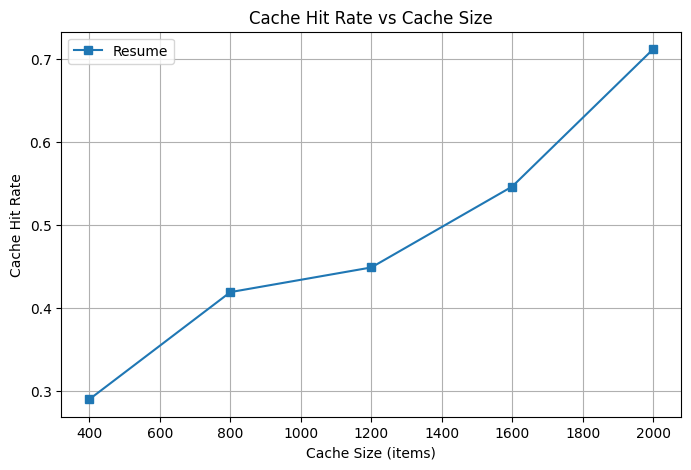

In [25]:
ENABLE_ARRIVAL_NUDGE = False
import matplotlib.pyplot as plt

cache_options = [400, 800, 1200, 1600, 2000]

hit_rates_reset = []
hit_rates_resume = []

for opt in cache_options:
    RSU_CACHE_ITEMS    = opt                      # keep as "items"
    VEH_CACHE_ITEMS    = opt                      # items
    RSU_CACHE_BITS     = RSU_CACHE_ITEMS * CONTENT_SIZE_BITS
    VEH_CACHE_BITS     = VEH_CACHE_ITEMS * CONTENT_SIZE_BITS

    print(f"Training and Testing with a cache size of {opt} items")

    # 1) train
    q_net, tgt_net = train_dqn_shared(
        rsus, vehicles,
        train_ratings, user_id_to_idx, movie_id_to_idx,
        episodes=1,                   
        batch_size=128,
        train_fraction=0.2,           
        use_prefix_window=True,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.999,
    )

    # optionally capture the end-of-train world state
    train_end_snapshot = snapshot_state(rsus, vehicles)

    # 2) evaluate on test set

    # (a) RESET
    # metrics_reset = evaluate_dqn_on_test(
    #     rsus, vehicles,
    #     test_ratings, user_id_to_idx, movie_id_to_idx,
    #     q_net,
    #     start_mode="reset",
    #     test_fraction=1
    # )
    # print("Evaluation (reset):", metrics_reset)

    # (b) RESUME
    metrics_resume = evaluate_dqn_on_test(
        rsus, vehicles,
        test_ratings, user_id_to_idx, movie_id_to_idx,
        q_net,
        start_mode="resume",
        resume_snapshot=train_end_snapshot,
        test_fraction=0.5
    )
    print("Evaluation (resume):", metrics_resume)

    # hit_rates_reset.append(metrics_reset['hit_ratio'])
    hit_rates_resume.append(metrics_resume['hit_ratio'])

# Plot
plt.figure(figsize=(8,5))
# plt.plot(cache_options, hit_rates_reset, marker="o", label="Reset")
plt.plot(cache_options, hit_rates_resume, marker="s", label="Resume")
plt.xlabel("Cache Size (items)")
plt.ylabel("Cache Hit Rate")
plt.title("Cache Hit Rate vs Cache Size")
plt.legend()
plt.grid(True)    
plt.show()
